In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [2]:
df = pd.read_csv('sales_data.csv', parse_dates=['Date'])

In [3]:
# 设置筛选条件
store_filter = df['Store ID'] == 'S001'       # 筛选门店
product_filter = df['Product ID'] == 'P0001'  # 筛选商品
date_filter = (df['Date'] >= '2022-01-01') & (df['Date'] <= '2023-12-31')  # 筛选日期范围

In [4]:
ts = df[store_filter & product_filter & date_filter].set_index("Date")['Units Sold']

In [5]:
type(ts)

pandas.core.series.Series

In [6]:
ts.to_csv('S001P0001Units_Sold.csv')

In [3]:
# 读取数据并设置时间索引
df = pd.read_csv("S001P0001Units_Sold.csv", parse_dates=["Date"])
ts = df.set_index("Date")["Units Sold"]

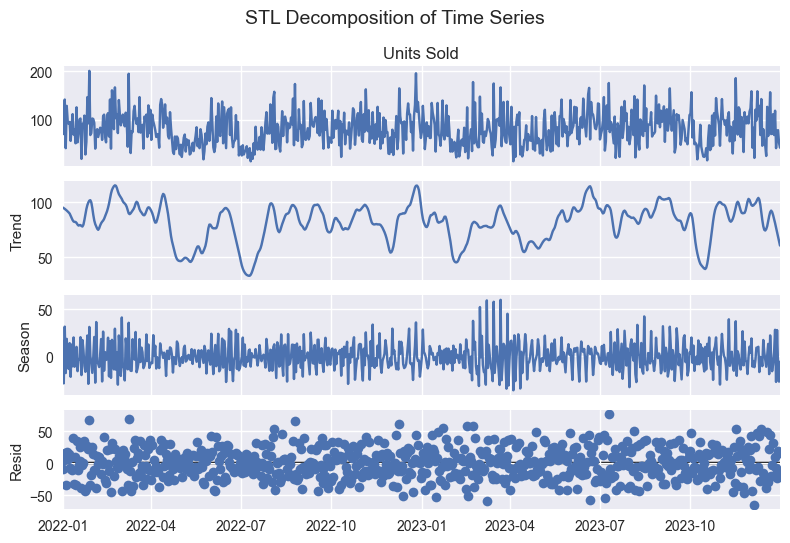

自动识别频率: D
设定周期: 7
季节性强度: 0.3706


In [20]:
seasonality_strength = analyze_seasonality(ts)

In [21]:
for p in [7, 14, 30, 90, 365]:
    stl = STL(ts, period=p)
    result = stl.fit()
    seasonal = result.seasonal
    resid = result.resid
    strength = max(0, 1 - resid.var() / (seasonal + resid).var())
    print(f"Period = {p}, Seasonal Strength = {strength:.4f}")

Period = 7, Seasonal Strength = 0.3706
Period = 14, Seasonal Strength = 0.3682
Period = 30, Seasonal Strength = 0.3830
Period = 90, Seasonal Strength = 0.4142
Period = 365, Seasonal Strength = 1.0000



=== STL 分解周期: 7 天 ===
Seasonal Strength (Period = 7): 0.3706


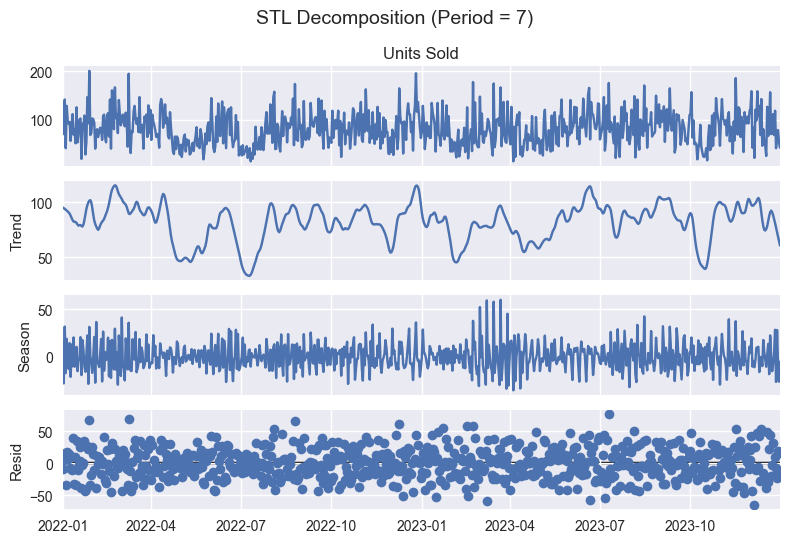


=== STL 分解周期: 14 天 ===
Seasonal Strength (Period = 14): 0.3682


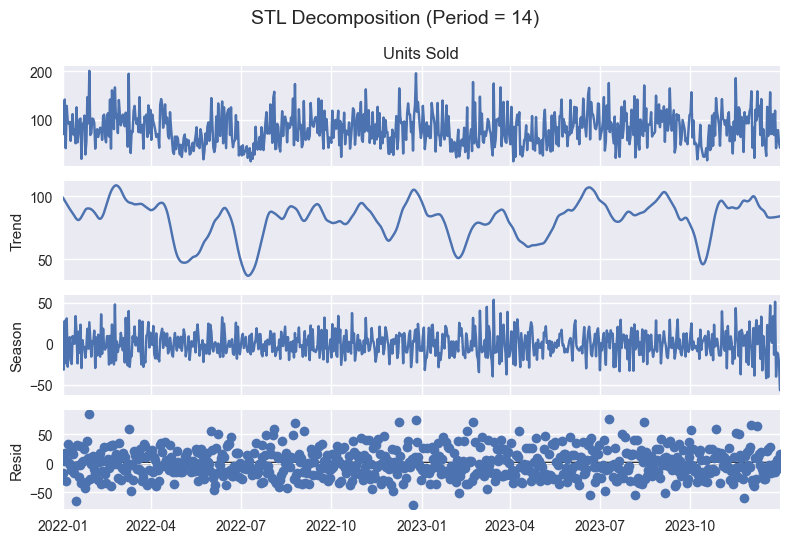


=== STL 分解周期: 30 天 ===
Seasonal Strength (Period = 30): 0.3830


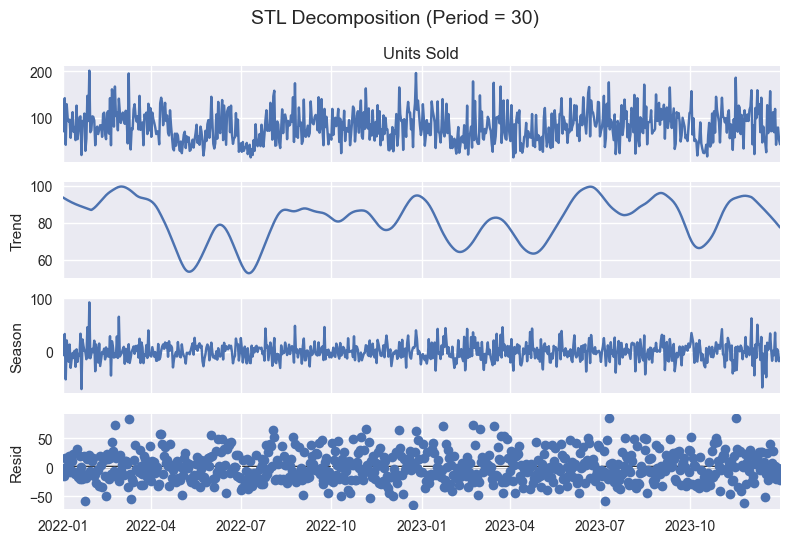


=== STL 分解周期: 90 天 ===
Seasonal Strength (Period = 90): 0.4142


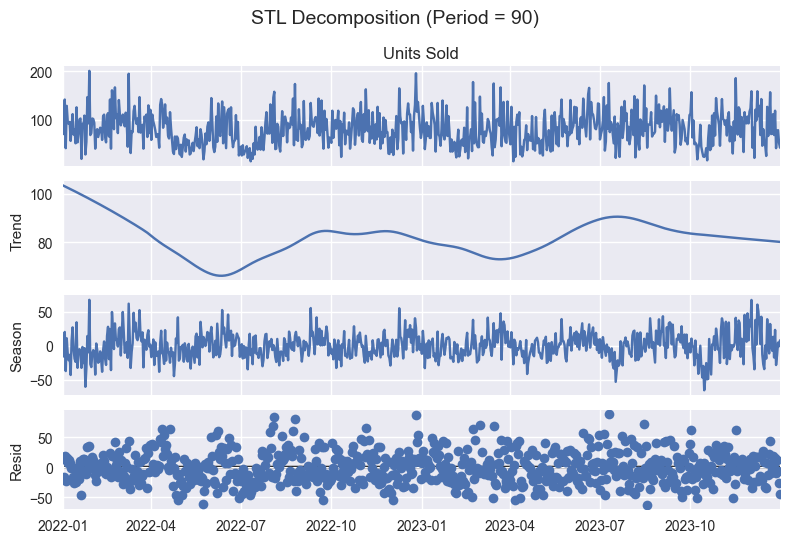


=== STL 分解周期: 365 天 ===
Seasonal Strength (Period = 365): 1.0000


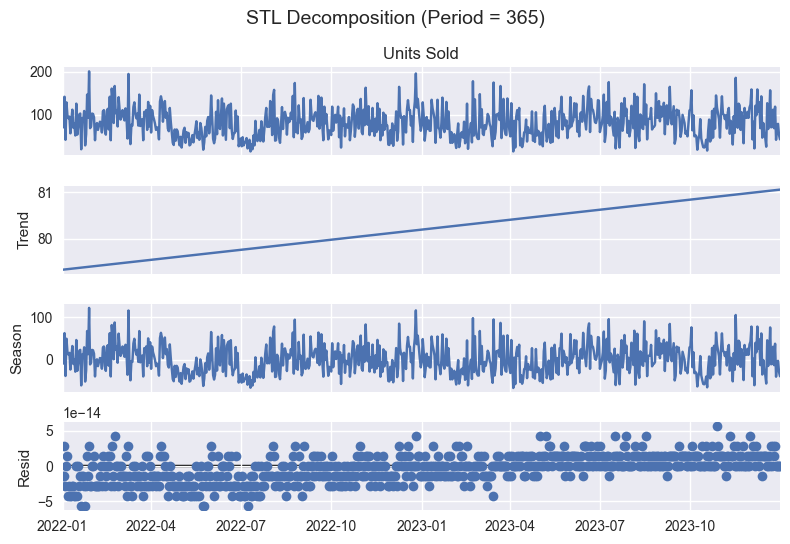

In [22]:
period_list = [7, 14, 30, 90, 365]

for period in period_list:
    print(f"\n=== STL 分解周期: {period} 天 ===")

    # 执行 STL 分解
    stl = STL(ts, period=period)
    result = stl.fit()

    # 提取分量
    seasonal = result.seasonal
    resid = result.resid

    # 计算季节性强度
    strength = max(0, 1 - np.var(resid) / np.var(seasonal + resid))
    print(f"Seasonal Strength (Period = {period}): {strength:.4f}")

    # 绘制分解图
    fig = result.plot()
    fig.suptitle(f"STL Decomposition (Period = {period})", fontsize=14)
    plt.tight_layout()
    plt.show()


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# === 主函数：多频率采样 + 多周期 STL 分解 ===
def multi_freq_stl(ts):
    """
    对日度时间序列数据进行多频率采样（日、周、月、季度），
    并在每个频率下执行多个周期的 STL 分解，输出图表和季节性强度。
    输入：ts 为 pandas Series，索引为 datetime 类型
    """

    # 定义采样频率与对应周期列表
    freq_config = {
        'D': [7, 14, 30],       # 日度采样：周周期、双周、月周期
        'W': [4, 8],            # 周度采样：月周期、双月周期
        'ME': [12],            # 月度采样：年周期
        'QE': [2, 3, 4]               # 季度采样：年周期
    }

    # 遍历每种采样频率
    for freq, periods in freq_config.items():
        print(f"\n=== 采样频率: {freq} ===")

        # 执行采样
        if freq == 'D':
            sampled_ts = ts  # 原始日度数据无需 resample
        else:
            sampled_ts = ts.resample(freq).sum()

        # 遍历每个周期值
        for period in periods:
            print(f"\n--- STL 分解周期: {period} ---")

            # 执行 STL 分解
            stl = STL(sampled_ts, period=period)
            result = stl.fit()

            # 提取分量
            seasonal = result.seasonal
            resid = result.resid

            # 计算季节性强度
            strength = max(0, 1 - np.var(resid) / np.var(seasonal + resid))
            print(f"Seasonal Strength: {strength:.4f}")

            # 绘制分解图
            fig = result.plot()
            fig.suptitle(f"STL Decomposition - Freq: {freq}, Period: {period}", fontsize=14)
            plt.tight_layout()
            plt.show()


=== 采样频率: D ===

--- STL 分解周期: 7 ---
Seasonal Strength: 0.3706


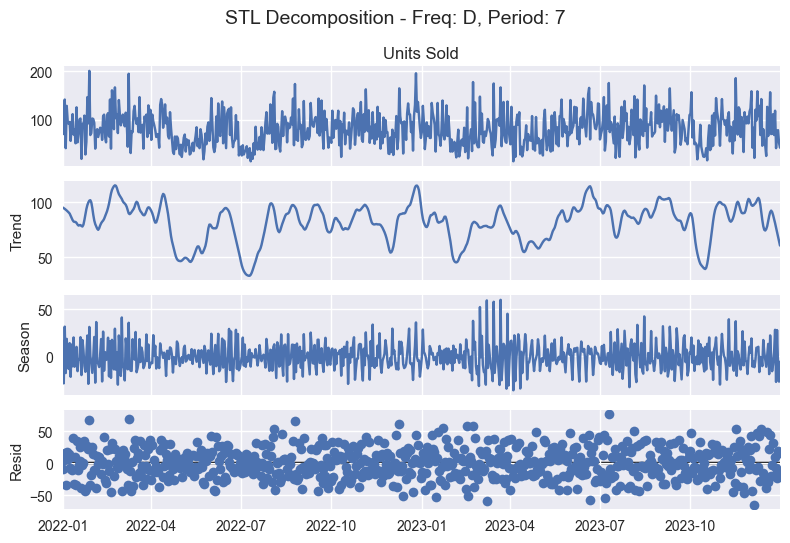


--- STL 分解周期: 14 ---
Seasonal Strength: 0.3682


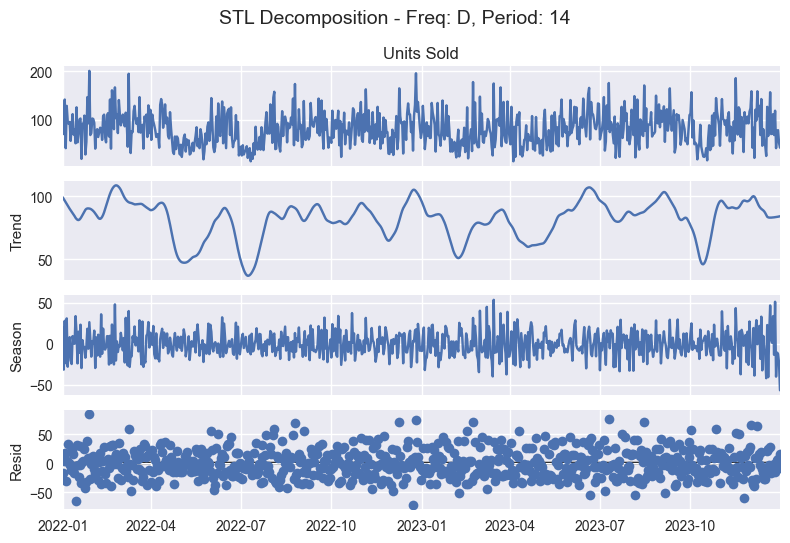


--- STL 分解周期: 30 ---
Seasonal Strength: 0.3830


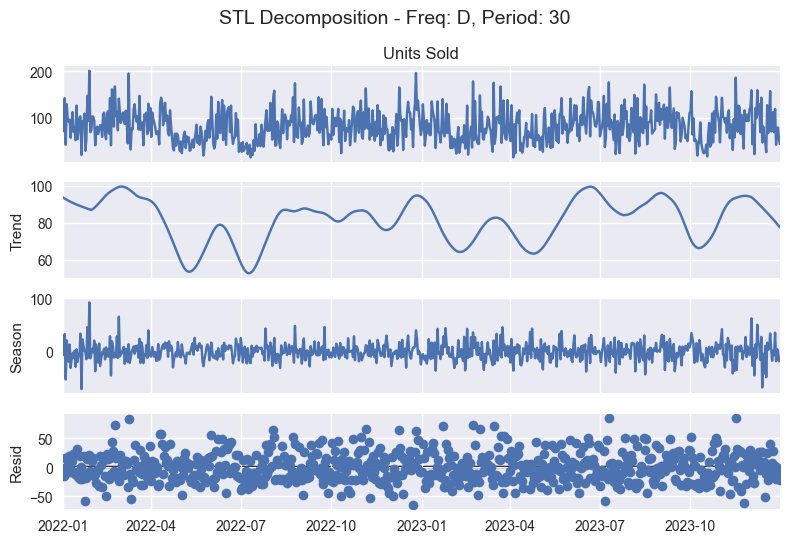


=== 采样频率: W ===

--- STL 分解周期: 4 ---
Seasonal Strength: 0.3593


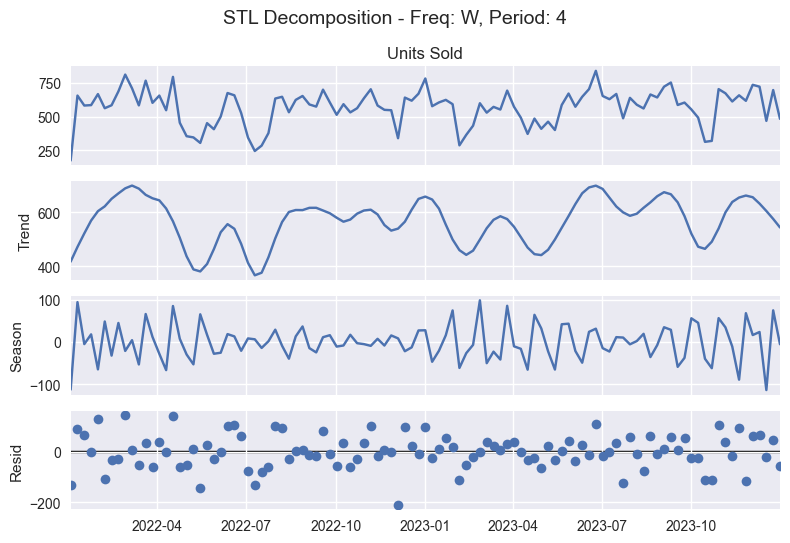


--- STL 分解周期: 8 ---
Seasonal Strength: 0.3881


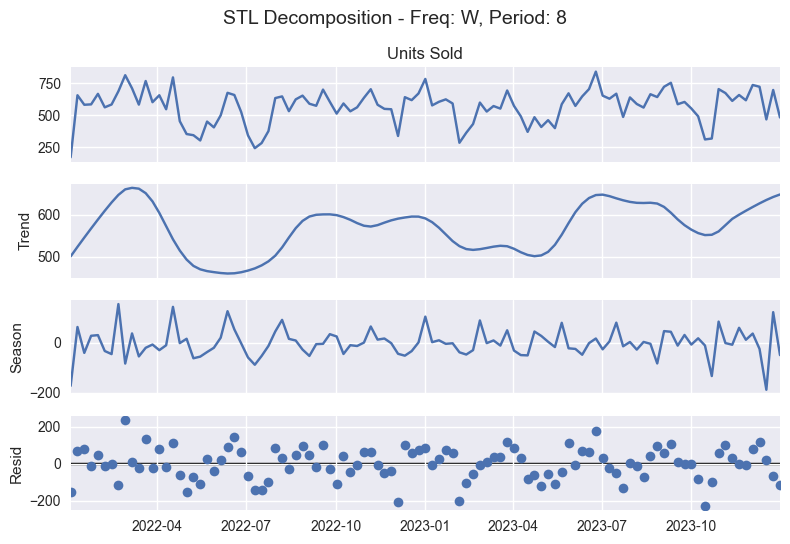


=== 采样频率: ME ===

--- STL 分解周期: 12 ---
Seasonal Strength: 1.0000


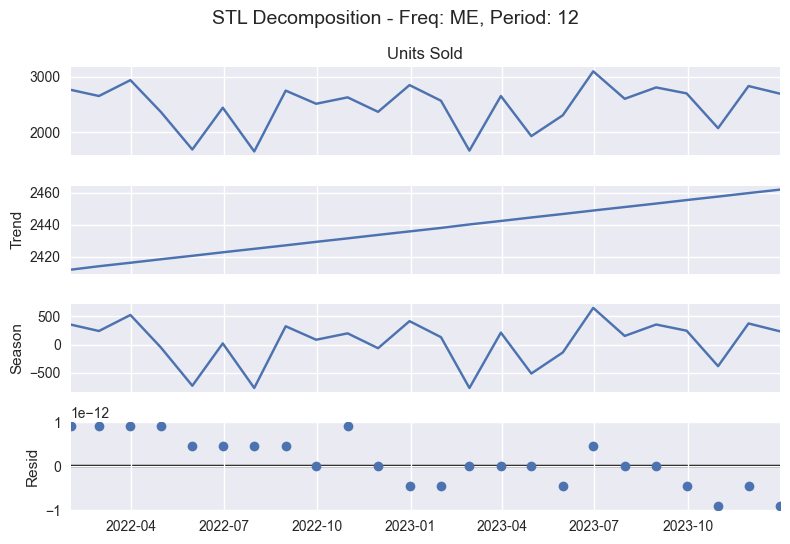


=== 采样频率: QE ===

--- STL 分解周期: 2 ---
Seasonal Strength: 0.4671


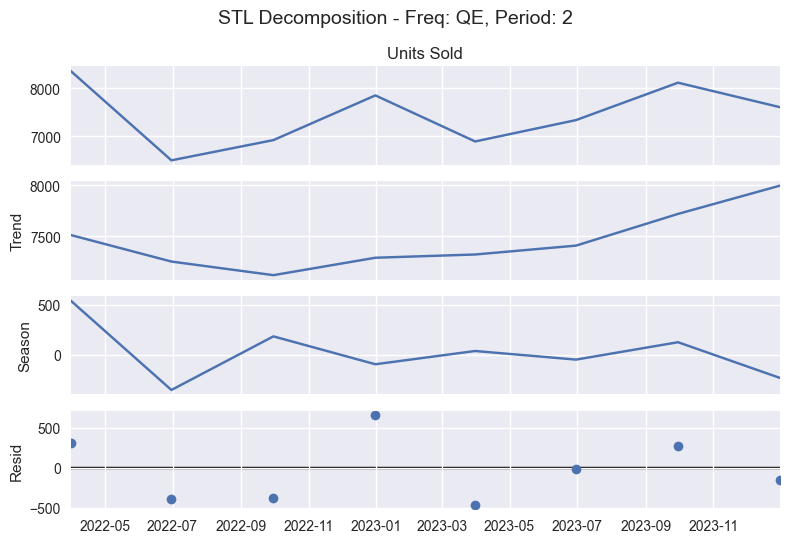


--- STL 分解周期: 3 ---
Seasonal Strength: 0.9924


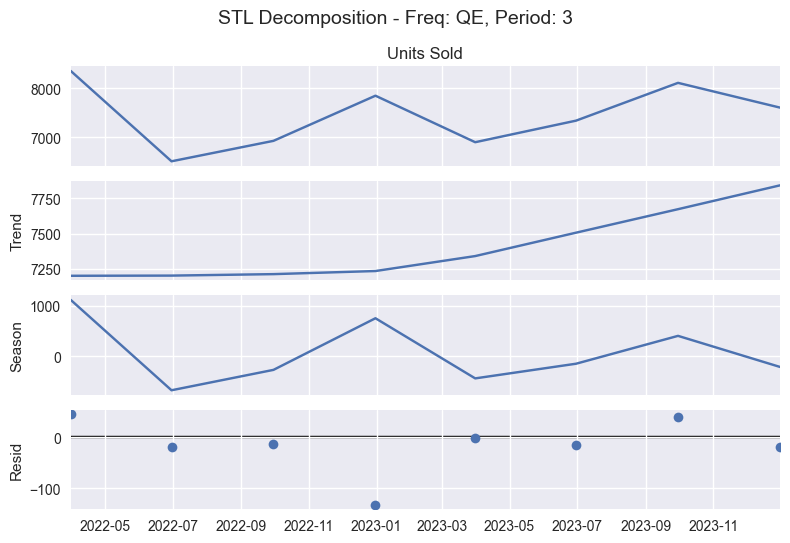


--- STL 分解周期: 4 ---
Seasonal Strength: 1.0000


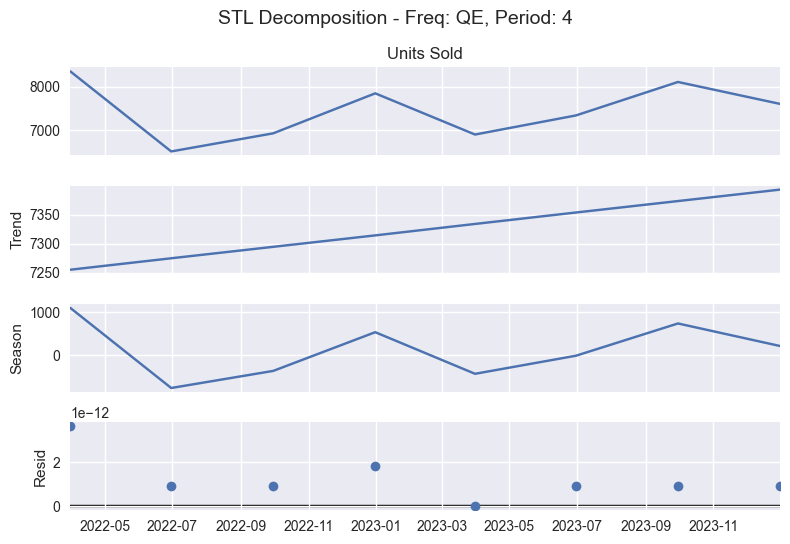

In [30]:
# 读取数据并转换为时间序列
df = pd.read_csv("S001P0001Units_Sold.csv", parse_dates=["Date"])
ts = df.set_index("Date")["Units Sold"]

# 执行多频率 STL 分解分析
multi_freq_stl(ts)

In [4]:
ts

Date
2022-01-01    102
2022-01-02     71
2022-01-03    142
2022-01-04     42
2022-01-05    129
             ... 
2023-12-27     42
2023-12-28     78
2023-12-29     79
2023-12-30     53
2023-12-31     43
Name: Units Sold, Length: 730, dtype: int64

In [7]:
monthly_ts = ts.resample('ME').sum()
monthly_ts

Date
2022-01-31    2766
2022-02-28    2654
2022-03-31    2939
2022-04-30    2368
2022-05-31    1694
2022-06-30    2444
2022-07-31    1659
2022-08-31    2751
2022-09-30    2515
2022-10-31    2630
2022-11-30    2370
2022-12-31    2850
2023-01-31    2569
2023-02-28    1674
2023-03-31    2654
2023-04-30    1934
2023-05-31    2308
2023-06-30    3097
2023-07-31    2604
2023-08-31    2808
2023-09-30    2701
2023-10-31    2077
2023-11-30    2833
2023-12-31    2696
Freq: ME, Name: Units Sold, dtype: int64

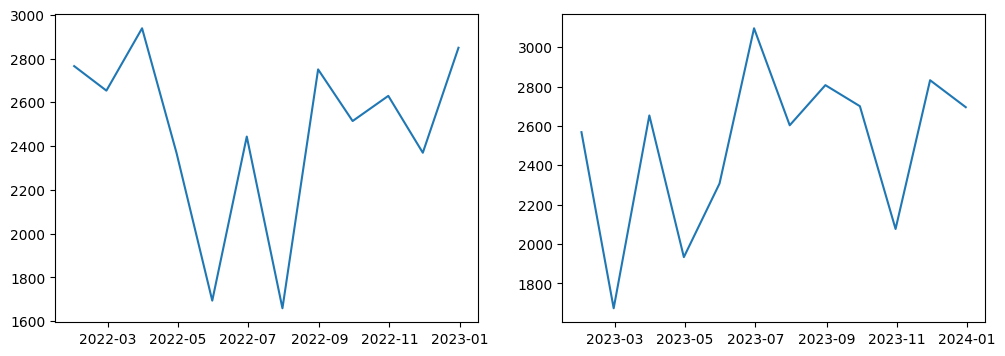

In [18]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(monthly_ts['2022'])
plt.subplot(1,2,2)
plt.plot(monthly_ts['2023'])

In [19]:
from statsmodels.tsa.seasonal import STL

# 日度
stl_daily = STL(ts, period=365).fit()
strength_daily = 1 - np.var(stl_daily.resid) / (np.var(stl_daily.resid) + np.var(stl_daily.seasonal))

# 月度
monthly_ts = ts.resample('ME').sum()
stl_monthly = STL(monthly_ts, period=12).fit()
strength_monthly = 1 - np.var(stl_monthly.resid) / (np.var(stl_monthly.resid) + np.var(stl_monthly.seasonal))

In [19]:
def analyze_seasonality(ts):
    """
    对时间序列数据进行自动频率识别、STL分解和季节性强度评估。
    输入：ts 为 pandas Series，索引为 datetime 类型
    输出：绘图 + 季节性强度值
    """

    # 自动识别频率（日度、周度、月度）
    inferred_freq = pd.infer_freq(ts.index)
    if inferred_freq is None:
        inferred_freq = 'D'  # 默认按日度处理

    # 根据频率设定周期参数
    freq_map = {'D': 7, 'W': 4, 'M': 12}
    period = freq_map.get(inferred_freq[0], 7)  # 取首字母匹配

    # 执行 STL 分解
    stl = STL(ts, period=period)
    result = stl.fit()

    # 计算季节性强度：max(0, 1 - Var(resid) / Var(seasonal + resid))
    resid = result.resid
    seasonal = result.seasonal
    strength = max(0, 1 - np.var(resid) / np.var(seasonal + resid))

    # 绘图
    plt.style.use('seaborn-v0_8')
    fig = result.plot()
    fig.suptitle('STL Decomposition of Time Series', fontsize=14)
    plt.tight_layout()
    plt.show()

    # 输出结果
    print(f"自动识别频率: {inferred_freq}")
    print(f"设定周期: {period}")
    print(f"季节性强度: {strength:.4f}")

    return strength

In [20]:
strength_daily

1.0

In [21]:
strength_monthly

1.0

In [22]:
ts

Date
2022-01-01    102
2022-01-02     71
2022-01-03    142
2022-01-04     42
2022-01-05    129
             ... 
2023-12-27     42
2023-12-28     78
2023-12-29     79
2023-12-30     53
2023-12-31     43
Name: Units Sold, Length: 730, dtype: int64